# ***CLEANING PHASE***

**About Dataset:**

---


This Dataset contains daily data about the situation of Covid-19 in Morocco.

The dataset includes 17 columns: date, confirmed cases, deaths, Recovered, and count of cases across each of the 12 Moroccan regions.
It is a good source for data visualization or exploring different models of disease transmission.

The dataset will be updated according to the official data each day at +01:00(GMT).

**Question:**
1. **Which regions were the most affected?**
2. **How did COVID-19 cases evolve over time in Morocco?**
3. **How do confirmed, recovered, and death cases compare over time?**

**setup**

In [1]:
import pandas as pd
import numpy as np

df_ = pd.read_csv("/content/corona_morocco.csv")

df_.head()

,Date,Confirmed,Deaths,Recovered,Excluded,Beni Mellal-Khenifra,Casablanca-Settat,Draa-Tafilalet,Dakhla-Oued Ed-Dahab,Fes-Meknes,Guelmim-Oued Noun,Laayoune-Sakia El Hamra,Marrakesh-Safi,Oriental,Rabat-Sale-Kenitra,Souss-Massa,Tanger-Tetouan-Al Hoceima
0,02/03/2020,1.0,NaN,NaN,28.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,03/03/2020,NaN,NaN,NaN,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/03/2020,2.0,NaN,NaN,34.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,05/03/2020,NaN,NaN,NaN,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,06/03/2020,NaN,NaN,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We got 194 rows, and 17 colomns.

In [2]:
df_.shape

(194, 17)

By showing the info of the data we can tell the accuracy is high and it's already cleaned and ready to use.

In [3]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       181 non-null    object 
 1   Confirmed                  172 non-null    float64
 2   Deaths                     161 non-null    float64
 3   Recovered                  160 non-null    float64
 4   Excluded                   169 non-null    float64
 5   Beni Mellal-Khenifra       158 non-null    float64
 6   Casablanca-Settat          161 non-null    float64
 7   Draa-Tafilalet             158 non-null    float64
 8   Dakhla-Oued Ed-Dahab       158 non-null    float64
 9   Fes-Meknes                 159 non-null    float64
 10  Guelmim-Oued Noun          158 non-null    float64
 11  Laayoune-Sakia El Hamra    158 non-null    float64
 12  Marrakesh-Safi             160 non-null    float64
 13  Oriental                   158 non-null    float64

Making sure of the amount of the non value we got before starting.

In [4]:
df_.isna().sum()

,0
Date,13
Confirmed,22
Deaths,33
Recovered,34
Excluded,25
Beni Mellal-Khenifra,36
Casablanca-Settat,33
Draa-Tafilalet,36
Dakhla-Oued Ed-Dahab,36
Fes-Meknes,35


Making copy of the dataframe we have read and using the old one as backup.

In [5]:
df = df_.copy()

Converting date into a usable data.

In [6]:
df["Date"] = pd.to_datetime(df["Date"], format = "%d/%m/%Y", errors = "coerce")
df["Date"].dtype

dtype('<M8[ns]')

Those are the totale values of every colomn.

In [7]:
df.sum(numeric_only = True)

,0
Confirmed,2116892.0
Deaths,40829.0
Recovered,1490837.0
Excluded,84961082.0
Beni Mellal-Khenifra,42786.0
Casablanca-Settat,579717.0
Draa-Tafilalet,92361.0
Dakhla-Oued Ed-Dahab,6069.0
Fes-Meknes,293743.0
Guelmim-Oued Noun,12301.0


**Totale confirmed, The totale of all the regieon, The deffrence.**

This represent the total value of the confirmed column.

In [8]:
df.sum(numeric_only = True).head(1).sum()

np.float64(2116892.0)

Those are the total confirmed cases in every region.

In [9]:
df.sum(numeric_only = True).tail(12).sum()

np.float64(2110923.0)

By substracting the two value we can know the amount of the non-value and add it in our analysis in case we need it.

In [10]:
deff = df.sum(numeric_only = True).head(1).sum() - df.sum(numeric_only = True).tail(12).sum()
deff

np.float64(5969.0)

# ***ANALYSIS PHASE***

**Setup**

In [11]:
import seaborn as sbs
import matplotlib.pyplot as plt

**1 - Which regions got the highest confirmed cases?**

In [12]:
df.sum(numeric_only = True).tail(12).sort_values(ascending = False)

,0
Casablanca-Settat,579717.0
Tanger-Tetouan-Al Hoceima,396532.0
Marrakesh-Safi,352073.0
Fes-Meknes,293743.0
Rabat-Sale-Kenitra,222217.0
Draa-Tafilalet,92361.0
Laayoune-Sakia El Hamra,50226.0
Oriental,43057.0
Beni Mellal-Khenifra,42786.0
Souss-Massa,19841.0


In [13]:
other = df.sum(numeric_only = True).tail(12).sort_values(ascending = False)[6:].sum().tolist() + deff.tolist()
other

180249.0

In [14]:
data = df.sum(numeric_only = True).tail(12).sort_values(ascending = False).tolist()[0:6]
data.append(other)

In [15]:
regions = ["Casablanca-Settat",
     "Tanger-Tetouan-Al Hoceima",
     "Marrakesh-Safi",
     "Fes-Meknes",
     "Rabat-Sale-Kenitra",
     "Draa-Tafilalet",
     "other"]

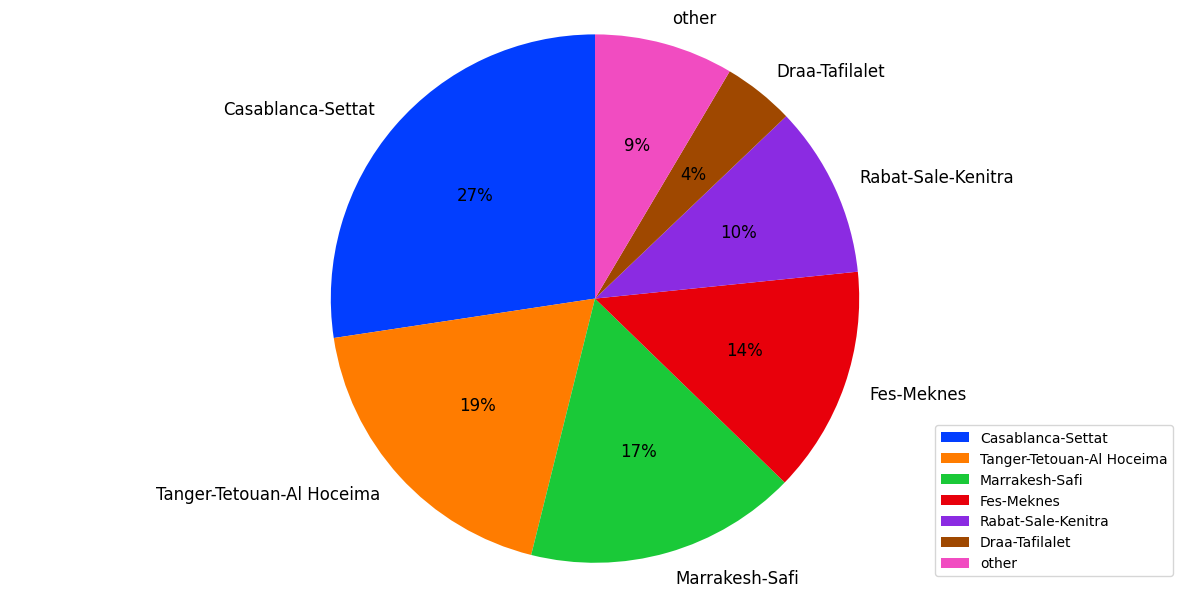

In [16]:
labels = regions
colors = sbs.color_palette('bright')
plt.figure(figsize=(12, 6))
plt.pie(data, labels=labels, colors=colors, autopct='%.f%%', textprops={'fontsize': 12}, startangle=90)
plt.legend(labels, loc='best', fontsize=10)
plt.axis('equal')
plt.tight_layout()
plt.show()

***-> Casablanca-Settat, Tanger-Tetouan-Al Hoceima and Marrakesh-Safi are top 3 regions that got confirmed cases.***

**2 - How have confirmed cases changed over time?**

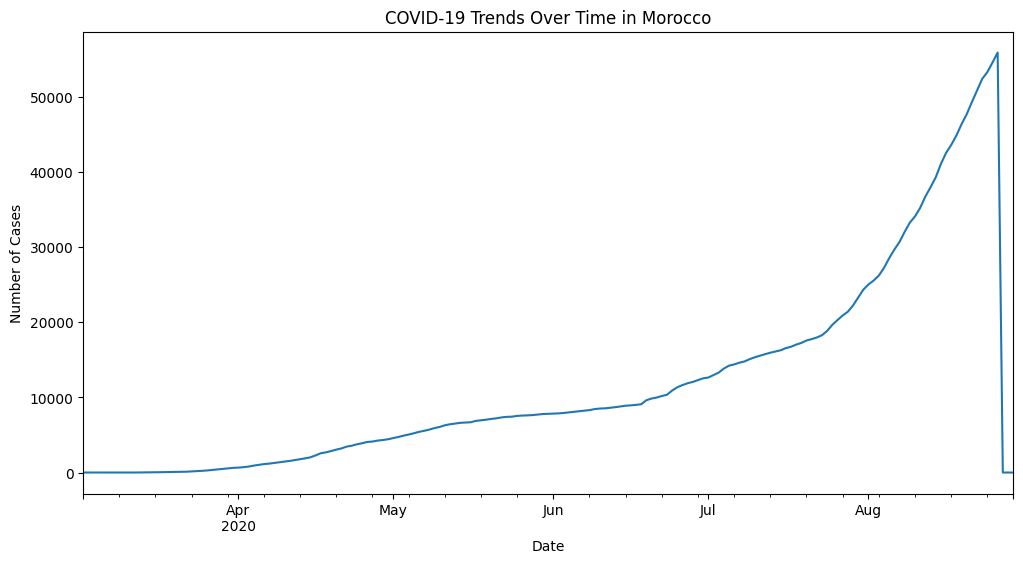

In [17]:
df.groupby("Date")["Confirmed"].sum().plot(figsize=(12,6))

plt.title("COVID-19 Trends Over Time in Morocco")
plt.xlabel("Date")
plt.ylabel("Number of Cases")

plt.show()

***-> At the end of august was the strongest hit mark for covid-19.***

**3 - what is the situation for those cases?**

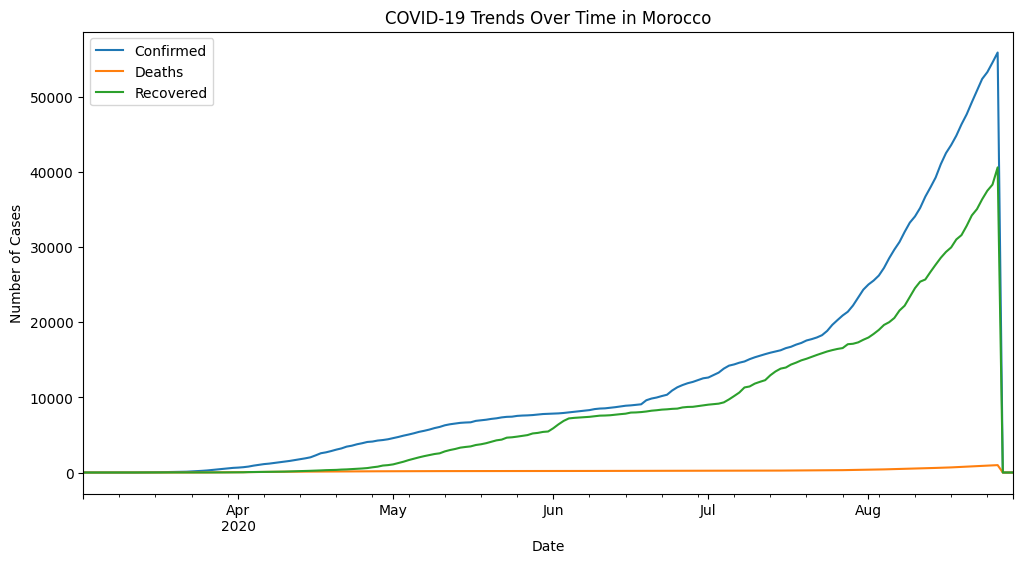

In [18]:
df.groupby("Date")[["Confirmed","Deaths","Recovered"]].sum().plot(figsize=(12,6))

plt.title("COVID-19 Trends Over Time in Morocco")
plt.xlabel("Date")
plt.ylabel("Number of Cases")

plt.show()

***-> The majority of the confirmed cases shows that recovered one where higher than the deaths record.***

# ***KEY FINDING***



*   **Casablanca-Settat got the highest confirmed cases.**
*   **The end of august was shown an incresing of confimed cases.**
*   **Recovered record are higher than deaths one.**



# ***Conclusion***

**This analysis highlights the progression of COVID-19 in Morocco across time and regions. The results show clear temporal trends and regional disparities in case distribution, providing insight into how the pandemic evolved within the country.**